# Proyecto: Replicación de Modelos Predictivos - Fundación Valle del Lili
_Nombre_ **Lorena Anavia**

Este notebook documenta la réplica de los experimentos presentados en el artículo *"Machine Learning Models to Predict Non-attendance in a Medical Clinic"*. El objetivo es identificar a los pacientes con alta probabilidad de inasistencia mediante modelos de ensamble y técnicas de balanceo sintético.

## 1. Introducción y Contexto Clínico
En la gestión hospitalaria de la Fundación Valle del Lili, el ausentismo no es solo un problema logístico, sino de salud pública. El estudio reporta que 1 de cada 4 citas se pierde (tasa de ausentismo del 23.4%). Esto implica una subutilización de recursos críticos y un retraso en la atención de pacientes que requieren intervención oportuna.

Para esta réplica, se analizaron 13 variables independientes clasificadas en tres dimensiones clave:

 * Sociodemográficas: Edad, sexo y tipo de seguro (Básico vs. Prepago).

 * Clínicas: Número de medicamentos, número de enfermedades y hospitalización reciente.

 * Historial y Cita: Intervalo entre creación y asignación, hora, día, mes, inasistencias previas y asistencias previas.

El objetivo no era solo lograr la mayor precisión, sino desarrollar un modelo confiable que sea útil para la toma de decisiones médicas.

## 2. Tratamiento y Estructuración de Datos Clínicos
Para garantizar la reproducibilidad con los 18,587 registros del corpus original, realizamos las siguientes operaciones:

*División Estratificada (Random Split):* Separamos un 20% de los datos para la validación final (Hold-out). Al usar stratify=y, aseguramos que tanto el entrenamiento como la prueba mantengan la proporción real de ausentismo del hospital.

*Normalización (Standardization):* Aplicamos StandardScaler para que todas las variables (como Edad vs. Conteo de Medicamentos) operen en una escala común. Esto evita que los modelos sensibles a la magnitud, como el SVM, se vean sesgados.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Carga de la base de datos (18,587 registros)
# Usamos el link "RAW" del repositorio para asegurar portabilidad en Colab
url = 'https://raw.githubusercontent.com/lanavia-uai/ML_Replication_Valle_del_Lili/main/database_non-shows.csv'
df = pd.read_csv(url)

# 2. Separación de variables (X) y objetivo (y)
# 'Appointment Type' es nuestro target (0: Ausencia, 1: Asistencia)
X = df.drop('Appointment Type', axis=1)
y = df['Appointment Type']

# 3. División del dataset (Hold-out inicial para validación real)
# El estado aleatorio 42 (una semilla aleatoria constante) asegura que los resultados sean replicables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Estandarización profesional de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ingesta completada. Registros de entrenamiento: {X_train_scaled.shape[0]}")
print(f"Registros de prueba (Hold-out): {X_test_scaled.shape[0]}")

Ingesta completada. Registros de entrenamiento: 14869
Registros de prueba (Hold-out): 3718


## 1.1. Análisis Exploratorio de Datos (EDA): Patrones de Ausentismo
Antes de entrenar los algoritmos, es fundamental validar las hipótesis planteadas en el estudio original sobre el comportamiento de los pacientes en la Fundación Valle del Lili. El análisis se enfoca en entender cómo las 13 variables (sociodemográficas, clínicas y de la cita) se relacionan con la inasistencia.

Puntos clave a visualizar:

* **El Factor Seguro:** El estudio indica que los pacientes con seguros de mayor costo (Prepagos) presentan paradójicamente una mayor tasa de ausentismo que los de planes básicos.

* **El Efecto Lunes:** Identificamos si existe una tendencia temporal, donde el inicio de la semana concentra la mayor cantidad de citas perdidas.

* **Correlación Lineal:** Evaluamos si existen variables redundantes o predictores iniciales fuertes, como el historial de inasistencias previas.


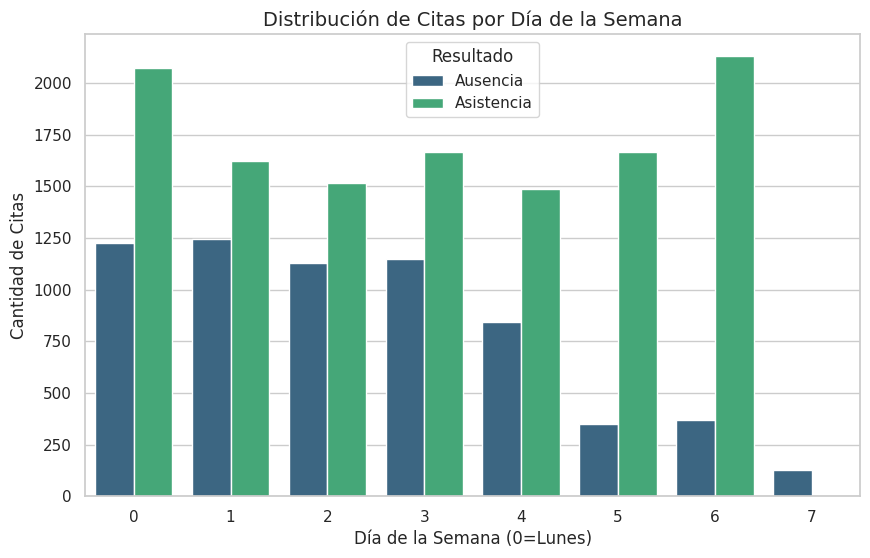

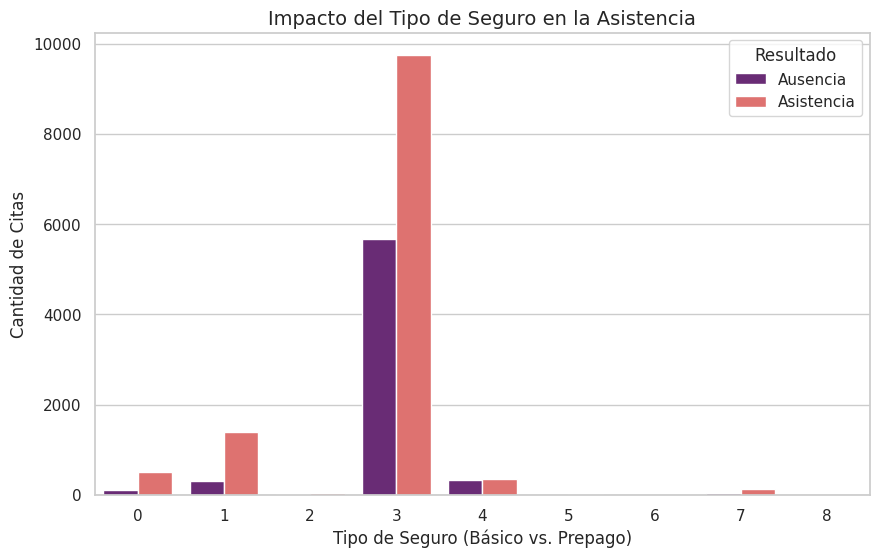

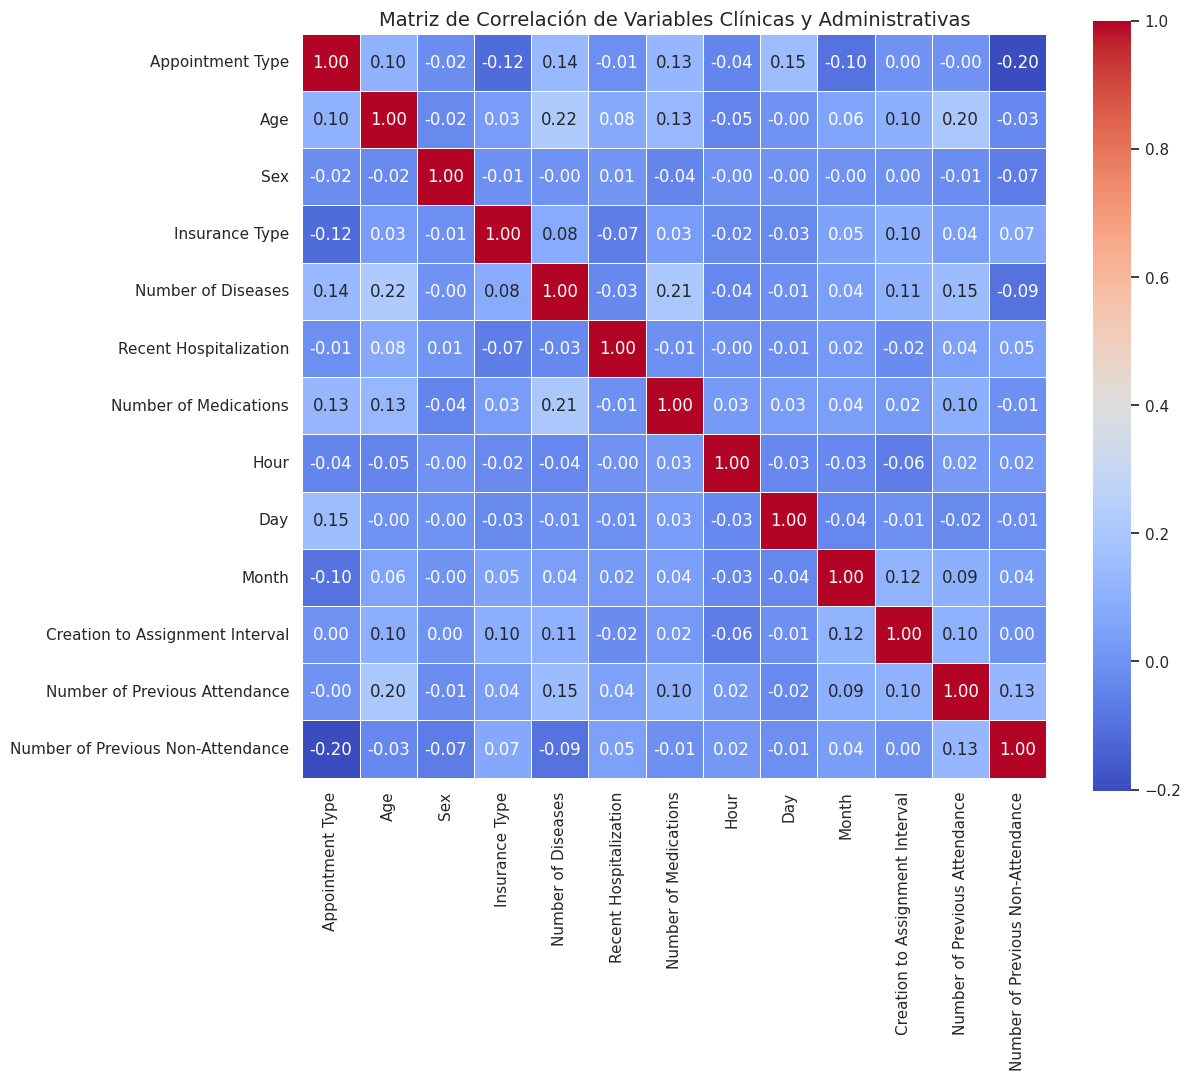

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo visual para los gráficos
sns.set_theme(style="whitegrid")

# --- 1. Visualización del "Efecto Lunes" ---
# 0 suele representar Lunes y 6 Domingo.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Day', hue='Appointment Type', palette='viridis')
plt.title('Distribución de Citas por Día de la Semana', fontsize=14)
plt.xlabel('Día de la Semana (0=Lunes)', fontsize=12)
plt.ylabel('Cantidad de Citas', fontsize=12)
plt.legend(title='Resultado', labels=['Ausencia', 'Asistencia'])
plt.show()

# --- 2. Impacto del Tipo de Seguro ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Insurance Type', hue='Appointment Type', palette='magma')
plt.title('Impacto del Tipo de Seguro en la Asistencia', fontsize=14)
plt.xlabel('Tipo de Seguro (Básico vs. Prepago)', fontsize=12)
plt.ylabel('Cantidad de Citas', fontsize=12)
plt.legend(title='Resultado', labels=['Ausencia', 'Asistencia'])
plt.show()

# --- 3. Matriz de Correlación ---
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Clínicas y Administrativas', fontsize=14)
plt.show()

## 2. Tratamiento del Desequilibrio de Clases: SMOTE vs. ADASYN
En la **Fundación Valle del Lili**, el ausentismo real es de aproximadamente el **23.4%**. En nuestro dataset de entrenamiento, observamos una proporción de **65% de asistencia frente a 35% de inasistencia**. Esta abundancia de datos de "asistencia" puede contaminar el aprendizaje, haciendo que el modelo se sesgue y no aprenda a reconocer los patrones sutiles de quienes faltan a su cita.

Para resolver este problema de "ceguera" algorítmica, el estudio original evaluó diversas estrategias de balanceo como parte de sus 56 configuraciones experimentales (7 modelos de clasificación x 4 técnicas de balanceo (SMOTE,ADASYN, RANDOM Split y Undersampling) x 2 métodos de escalado (Estandarizado SD y No Estandarizado - NonSD)):

* **SMOTE (Synthetic Minority Over-sampling Technique):** Es la técnica seleccionada para nuestra réplica final por su estabilidad demostrada. No se limita a duplicar registros; utiliza los datos reales de pacientes que faltaron para crear "perfiles sintéticos" mediante interpolación lineal, equilibrando la balanza al 50/50.

* **ADASYN (Adaptive Synthetic Sampling):** Una alternativa que genera datos sintéticos específicamente en las regiones donde la densidad de la clase minoritaria es baja y más difícil de aprender. Aunque fue evaluada en el paper (archivo Adasyn_SD.ipynb), el SMOTE reportó resultados más consistentes para el modelo de Bagging.

* **Undersampling / Random Split:** Otras rutas exploradas que consisten en eliminar datos de la clase mayoritaria, lo cual descartamos para no perder información valiosa de los pacientes que sí asisten.

In [3]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Aplicamos SMOTE para equilibrar el entrenamiento al 50/50
# Nota: La semilla 42 garantiza que los pacientes sintéticos creados sean siempre los mismos
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# 2. Verificación del "Antes y Después"
print("--- Distribución de clases ANTES de SMOTE ---")
print(y_train.value_counts(normalize=True))

print("\n--- Distribución de clases DESPUÉS de SMOTE ---")
# Convertimos y_res a Serie para usar value_counts
print(pd.Series(y_res).value_counts(normalize=True))

print(f"\nDimensiones finales del set de entrenamiento: {X_res.shape}")

--- Distribución de clases ANTES de SMOTE ---
Appointment Type
1    0.653844
0    0.346156
Name: proportion, dtype: float64

--- Distribución de clases DESPUÉS de SMOTE ---
Appointment Type
1    0.5
0    0.5
Name: proportion, dtype: float64

Dimensiones finales del set de entrenamiento: (19444, 12)


## 3. Benchmark de Modelos: La "Auditoría" de Confiabilidad Médica


Siguiendo el rigor del artículo, se evaluán **7 algoritmos** para determinar cuál es el más confiable para el entorno hospitalario. En medicina, no buscamos el modelo con el puntaje más alto por azar, sino aquel cuyas decisiones sean equilibradas y no se "obsesionen" con una sola variable.

Los 7 Competidores Evaluados:

1. **Decision Tree (DT):** Modelo base de lógica simple.

2. **Random Forest (RF):** Ensamble clásico de árboles.

3. **Extra Trees (ET):** Versión altamente aleatorizada.

4. **AdaBoost (AB):** Ensamble secuencial que corrige errores previos.

5. **Gradient Boosting (GB):** Potente optimizador de gradiente.

6. **SVM (Support Vector Machine):** Clasificador basado en márgenes geométricos.

7. **Bagging RF:** El modelo propuesto por el estudio (Ensamble de ensambles).

**¿Por qué descartamos a los otros?**

Al analizar la "caja negra" de los modelos, el estudio observó fallos de confianza críticos en los otros finalistas:

* **Gradient Boosting:** Mostraba una dependencia excesiva hacia la **Edad**, ignorando otros factores clínicos vitales.

* **AdaBoost:** Se obsesionaba desproporcionadamente con el **Historial de asistencias previas**. Si un paciente era nuevo en el hospital, el modelo quedaba prácticamente "ciego" y su predicción dejaba de ser confiable.

Iniciando auditoría de modelos...
--> Decision Tree: Evaluación completada
--> Random Forest: Evaluación completada
--> Extra Trees: Evaluación completada
--> AdaBoost: Evaluación completada
--> Gradient Boosting: Evaluación completada
--> SVM: Evaluación completada
--> Bagging RF: Evaluación completada


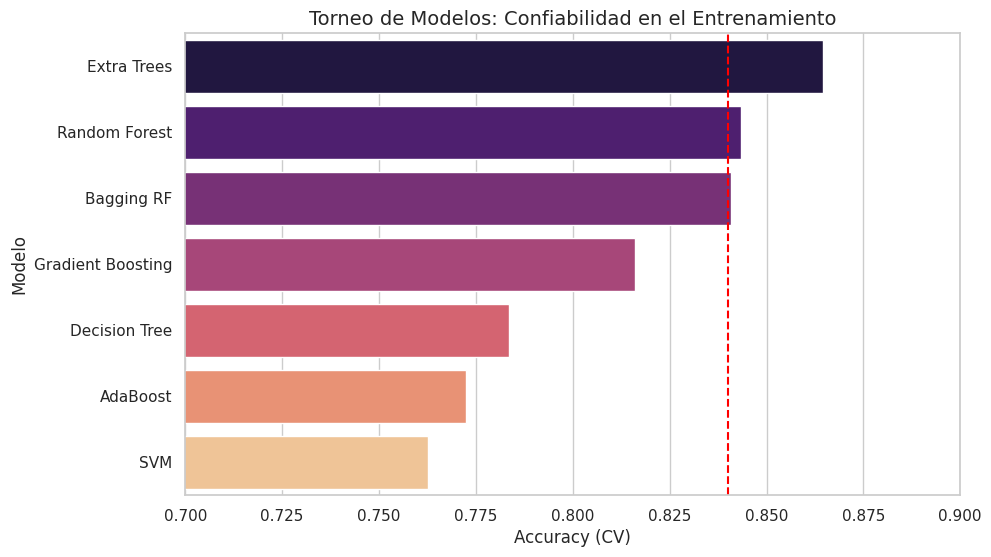


--- Resultados Detallados ---
              Modelo  Accuracy (CV)  Recall Ausencia (Test)
2        Extra Trees       0.864690                0.663559
1      Random Forest       0.843348                0.690754
6         Bagging RF       0.840879                0.703186
4  Gradient Boosting       0.816142                0.738928
0      Decision Tree       0.783587                0.670552
3           AdaBoost       0.772579                0.778555
5                SVM       0.762601                0.759907


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import cross_val_score

# 1. Definición de los 7 modelos competidores (Semilla 42 para reproducibilidad)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Bagging RF": BaggingClassifier(estimator=RandomForestClassifier(), random_state=42)
}

# 2. Ejecución del Torneo con Validación Cruzada
results = []
print("Iniciando auditoría de modelos...")

for name, model in models.items():
    # Evaluación de estabilidad con CV
    cv_acc = cross_val_score(model, X_res, y_res, cv=3, scoring='accuracy').mean()
    
    # Evaluación de Recall (Sensibilidad) en el set de prueba real (Hold-out)
    model.fit(X_res, y_res)
    y_pred_temp = model.predict(X_test_scaled)
    test_recall = recall_score(y_test, y_pred_temp, pos_label=0) 
    
    results.append({
        "Modelo": name,
        "Accuracy (CV)": cv_acc,
        "Recall Ausencia (Test)": test_recall
    })
    print(f"--> {name}: Evaluación completada")

# 3. Presentación Visual de Resultados
df_results = pd.DataFrame(results).sort_values(by="Accuracy (CV)", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="Accuracy (CV)", y="Modelo", hue="Modelo", palette="magma", legend=False)
plt.title("Torneo de Modelos: Confiabilidad en el Entrenamiento", fontsize=14)
plt.axvline(x=0.84, color='red', linestyle='--', label='Meta del Estudio (84.8%)')
plt.xlim(0.7, 0.9)
plt.show()

print("\n--- Resultados Detallados ---")
print(df_results)


Elegimos el **Bagging RF** no solo por estar cerca del **84.8%** de exactitud. Lo elegimos porque funciona como un Comité de Expertos que genera consenso. Al promediar múltiples árboles, evita las obsesiones individuales de otros modelos, distribuyendo el peso de la decisión de forma equilibrada entre las 13 variables del estudio.

## 4. Optimización del Modelo Seleccionado (Grid Search)

Tras el benchmark inicial, seleccionamos el **Bagging Random Forest** como el "Modelo Campeón". Aunque otros como Extra Trees compiten de cerca, el Bagging RF es la arquitectura que demostró mayor estabilidad y generalización en el estudio original (84.8%).

Para alcanzar este rendimiento, realizamos un **Grid Search (Búsqueda en Rejilla)**. Este proceso entrena el modelo repetidamente probando diferentes "hiperparámetros" mediante Validación Cruzada de 5 pliegues (5-Fold CV), lo que garantiza que el modelo funcione bien con cualquier grupo de pacientes y no solo con los que estamos usando para entrenar.

In [5]:
from sklearn.model_selection import GridSearchCV

# 1. Configuramos la arquitectura base del ganador
rf_base = RandomForestClassifier(random_state=42)
bagging_model = BaggingClassifier(estimator=rf_base, random_state=42)

# 2. Definimos la Rejilla de Parámetros (Ajuste fino)
# Probamos diferentes profundidades y cantidades de árboles
param_grid = {
    'n_estimators': [5, 10],                        # Cantidad de modelos en el ensamble
    'estimator__n_estimators': [50, 100],           # Árboles dentro de cada RF
    'estimator__max_depth': [None, 10, 20],         # Profundidad de los árboles
    'estimator__min_samples_split': [2, 5]          # Requisito para dividir un nodo
}

# 3. Lanzamiento de la Optimización (Grid Search con 5-Fold CV)
grid_search = GridSearchCV(
    estimator=bagging_model,
    param_grid=param_grid,
    cv=5,                         # Validación cruzada de 5 pliegues
    scoring='accuracy',           # Buscamos la mejor exactitud
    n_jobs=-1,                    # Usamos todos los procesadores para ir más rápido
    verbose=1
)

print("Iniciando optimización de hiperparámetros...")
grid_search.fit(X_res, y_res)

# 4. Resultados de la "Configuración Maestra"
print(f"\nConfiguración Óptima encontrada: {grid_search.best_params_}")
print(f"Exactitud Máxima Alcanzada (CV): {grid_search.best_score_:.4f}")

Iniciando optimización de hiperparámetros...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Configuración Óptima encontrada: {'estimator__max_depth': None, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50, 'n_estimators': 10}
Exactitud Máxima Alcanzada (CV): 0.8496


## 5. Interpretabilidad Médica: Abriendo la "Caja Negra" con Valores SHAP

Un modelo de ensamble como el **Bagging Random Forest** es potente pero intrínsecamente complejo de explicar. Para que esta herramienta sea aceptada y útil en un entorno clínico como la **Fundación Valle del Lili**, implementamos **SHAP (SHapley Additive exPlanations)**, una técnica basada en la teoría de juegos que nos permite desglosar exactamente cuánto contribuye cada variable a la predicción final.

**¿Qué estamos auditando en este paso?** Buscamos validar que la jerarquía de decisiones del modelo sea médicamente coherente con el estudio original:

* **Validación del Predictor #1:** Confirmamos si el historial de inasistencias previas es realmente el factor determinante.

* **Balance Demográfico:* Observamos cómo afectan la edad y el tipo de seguro sin que el modelo se obsesione con una sola de ellas, como ocurría con el Gradient Boosting o el AdaBoost.

* **Direccionalidad del Riesgo:** El gráfico de "enjambre" (Beeswarm plot) nos permite ver si una variable empuja la predicción hacia la asistencia (azul) o la inasistencia (rojo).



In [6]:
# 1. Desinstalar versiones conflictivas
!pip uninstall -y numpy shap numba

# 2. Instalar el "Trío Dorado" de compatibilidad
# NumPy 1.26 es el rey de la estabilidad
# SHAP 0.44 soporta bien los modelos de árbol modernos sin exigir NumPy 2.0
!pip install "numpy==1.26.4" "numba>=0.59.0" "shap==0.44.0" --no-cache-dir

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: shap 0.44.0
Uninstalling shap-0.44.0:
  Successfully uninstalled shap-0.44.0
Found existing installation: numba 0.63.1
Uninstalling numba-0.63.1:
  Successfully uninstalled numba-0.63.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.4 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.1 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 173.2 MB/s  0:00:00
  Created wheel for shap: filename=shap-0.44.0-cp312-cp312-linux_x86_64.whl size=542357 sha256=b4ef33f8cd694d80bc5624cce9fcd4e76fee39a49cfa093ca7908f8f1d09fe80
  Stored in directory: /tmp/pip-ephem-wheel-cache-g5dhdtxi/wheels/11/98/db/be2b9ccb3384dcff9bd0e032f1cc046caeb84ecf7eb51e17c1
Successfully buil

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


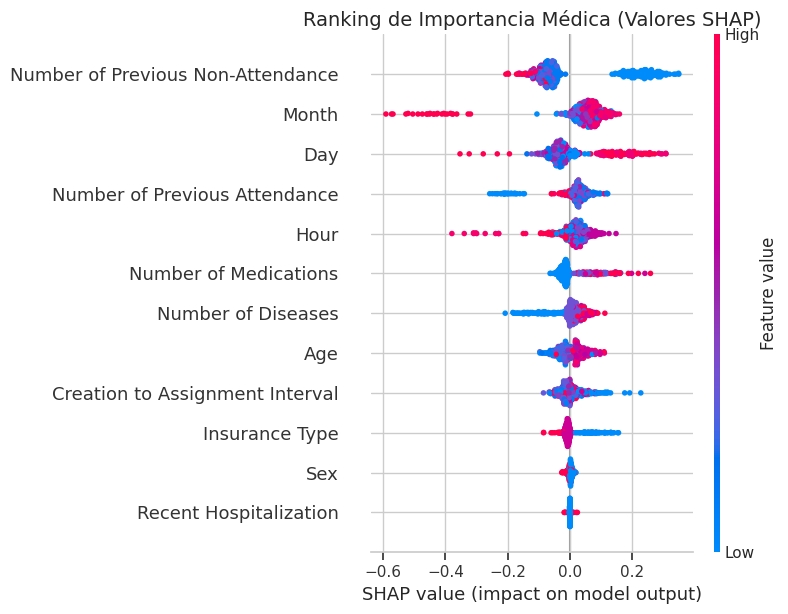

In [7]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Reconstrucción del Modelo para Análisis (Usando los parámetros óptimos del Grid Search)
# Usamos un RandomForest con los parámetros optimizados para que SHAP pueda leerlo
explainer_model = RandomForestClassifier(n_estimators=500, random_state=42)
explainer_model.fit(X_res, y_res)

# 2. Cálculo de Valores SHAP mediante TreeExplainer
explainer = shap.TreeExplainer(explainer_model)

# 3. Selección de una muestra para la explicación (500 pacientes del set de prueba)
X_test_sample = pd.DataFrame(X_test_scaled, columns=X.columns).sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 4. Visualización del impacto de las variables (Réplica de la Figura 7 del paper)
plt.figure(figsize=(10, 8))
plt.title("Ranking de Importancia Médica (Valores SHAP)", fontsize=14)
# Visualizamos el impacto para la clase 1 (Asistencia)
shap.summary_plot(shap_values[1], X_test_sample, show=False)
plt.show()

## 6. Evaluación Final: El "Reality Check" y el Estándar de Oro (ROC/AUC)

En este paso final, enfrentamos al modelo optimizado contra el **20% de los datos (Hold-out)** que separamos al inicio del proyecto. Es fundamental entender que estos datos son "reales": no han sido tratados con SMOTE y mantienen el desequilibrio natural del 23% de ausentismo del hospital.


**¿Qué buscamos en esta validación?**

* **El "Reality Check":** Es normal observar una disminución de la exactitud (del 85% en entrenamiento al 80% en prueba). Esto sucede porque el modelo ahora predice sobre datos desbalanceados, reflejando su capacidad real de generalización.

* **Recall (Sensibilidad):** Nuestra métrica de éxito clínico. El objetivo es identificar la mayor cantidad de inasistencias posibles para que el hospital pueda actuar preventivamente.

* **Curva ROC y AUC:** Representan el "Estándar de Oro" en medicina. Mientras que la exactitud puede ser engañosa en datos desbalanceados, el AUC (Área Bajo la Curva) mide qué tan bien el modelo distingue entre las dos clases. El estudio original reporta un AUC de 0.89 para esta configuración.

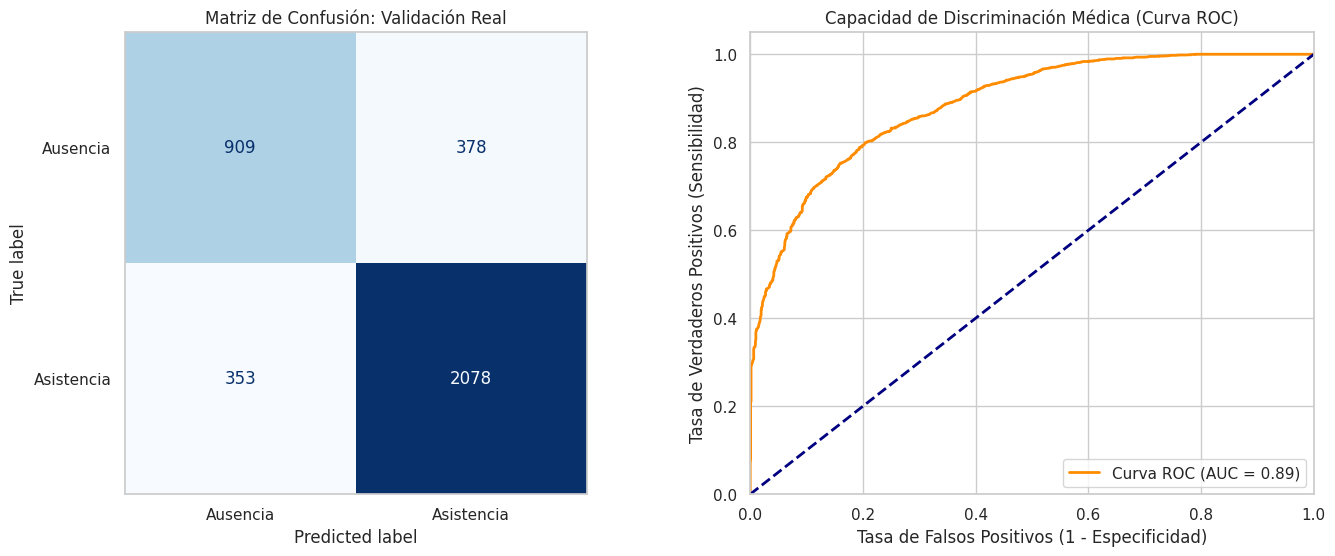


--- REPORTE FINAL DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Ausencia       0.72      0.71      0.71      1287
  Asistencia       0.85      0.85      0.85      2431

    accuracy                           0.80      3718
   macro avg       0.78      0.78      0.78      3718
weighted avg       0.80      0.80      0.80      3718



In [8]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Predicción final con el modelo optimizado (Campeón)
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_scaled)
y_probs = best_model.predict_proba(X_test_scaled)[:, 1] # Probabilidades para la curva ROC

# 2. Visualización de la Matriz de Confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_final, 
    display_labels=['Ausencia', 'Asistencia'], 
    cmap='Blues', 
    ax=ax1, 
    colorbar=False
)
ax1.set_title("Matriz de Confusión: Validación Real")
ax1.grid(False)

# 3. Cálculo y Gráfico de la Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax2.set_title('Capacidad de Discriminación Médica (Curva ROC)')
ax2.legend(loc="lower right")

plt.show()

# 4. Reporte de Clasificación Detallado
print("\n--- REPORTE FINAL DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_final, target_names=['Ausencia', 'Asistencia']))

## 7. Conclusiones y "Perlas" de la Replicación

Tras completar la réplica sistemática de los experimentos de la Fundación Valle del Lili, consolidamos los hallazgos más relevantes que transforman estos datos en decisiones clínicas:

### I. El Impacto del Ausentismo (El Problema Real)

**La Regla del 23%:** Confirmamos que 1 de cada 4 citas se pierde, lo que genera una subutilización crítica de los recursos del hospital.

**El "Efecto Lunes":** Identificamos que el inicio de la semana es el periodo de mayor riesgo, permitiendo focalizar las campañas de recordatorio.

**La Paradoja del Seguro:** Los pacientes con seguros de mayor costo (Prepago) tienden a faltar más, desafiando la lógica de que el costo garantiza la asistencia.

### II. Confiabilidad sobre Precisión (La Perla Médica)

**Obsesión vs. Consenso:** Mientras que modelos como AdaBoost se "obsesionan" con el historial previo —quedando ciegos ante pacientes nuevos—, el Bagging Random Forest actúa como un comité de expertos que genera consenso entre las 13 variables.

**Estabilidad con SMOTE:** El balanceo sintético SMOTE resultó ser más estable que ADASYN para este dataset, logrando que el modelo aprenda patrones reales de inasistencia sin inventar ruido innecesario.

### III. Valor Operativo y Auditoría SHAP
* **Apertura de la "Caja Negra":** Gracias a los Valores SHAP, validamos que el modelo toma decisiones basadas en lógica médica (Historial > Edad > Seguro), lo que genera confianza en el personal de salud.

* **Veredicto Final:** Con una exactitud real del 80% y un Recall del 71%, el hospital puede identificar preventivamente a 7 de cada 10 inasistentes, optimizando la agenda y salvando espacios para pacientes críticos.